# Basic Usage of Diffraction Package

This notebook demonstrates the basic functionality of the diffraction package for X-ray diffraction calculations.

In [12]:
k0

0.5996015695744039

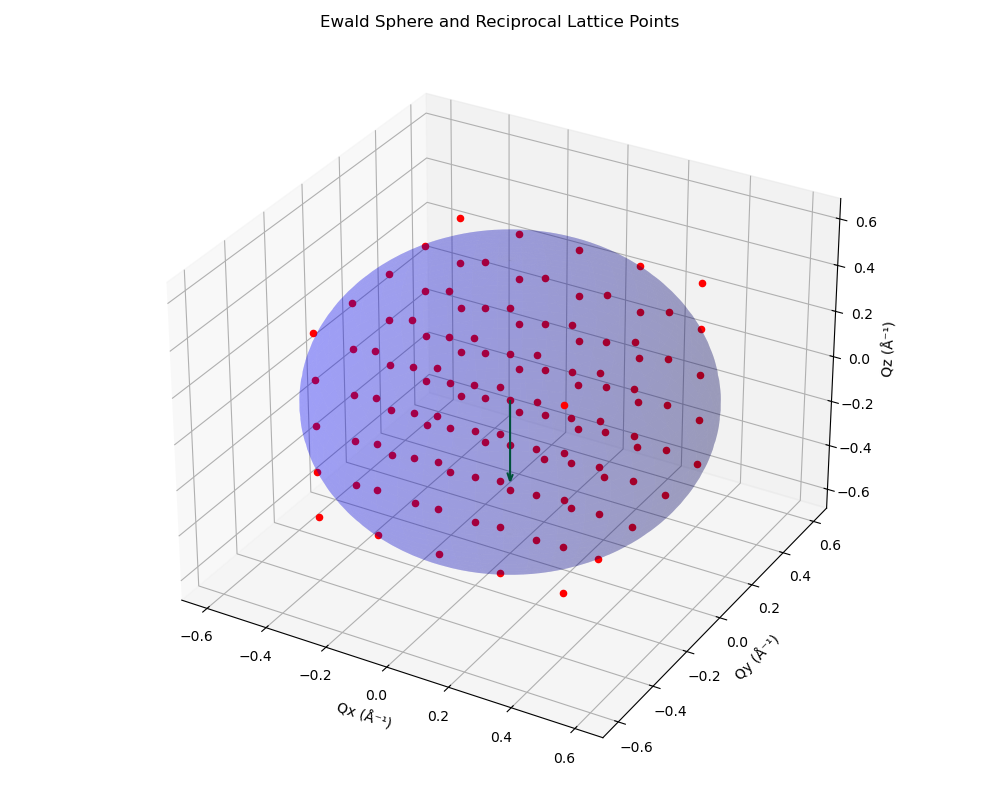

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants
h = 6.626e-34  # Planck's constant (J·s)
c = 3e8        # Speed of light (m/s)
e = 1.602e-19  # Electron charge (C)

# User inputs
a, b, c = 5.0, 5.0, 5.0  # Unit cell parameters (Å)
alpha, beta, gamma = np.deg2rad(90), np.deg2rad(90), np.deg2rad(90)  # Angles (radians)
energy_keV = 12.4  # X-ray energy (keV)

# Convert energy to wavelength (Å)
energy_J = energy_keV * 1000 * e
wavelength = h * c / energy_J * 1e10*1e8  # in Å

# Reciprocal lattice vectors (for a general lattice)
# Metric tensor for reciprocal lattice
V = a * b * c * np.sqrt(1 + 2*np.cos(alpha)*np.cos(beta)*np.cos(gamma) - np.cos(alpha)**2 - np.cos(beta)**2 - np.cos(gamma)**2)
a_star = (b * c * np.sin(alpha)) / V
b_star = (a * c * np.sin(beta)) / V
c_star = (a * b * np.sin(gamma)) / V

# Reciprocal lattice basis vectors
G_a = np.array([a_star, 0, 0])
G_b = np.array([b_star * np.cos(gamma), b_star * np.sin(gamma), 0])
G_c = np.array([
    c_star * np.cos(beta),
    c_star * (np.cos(alpha) - np.cos(beta)*np.cos(gamma)) / np.sin(gamma),
    c_star * np.sqrt(1 - np.cos(beta)**2 - ((np.cos(alpha) - np.cos(beta)*np.cos(gamma)) / np.sin(gamma))**2)
])

# Ewald sphere radius
k0 = 1 / wavelength

# Sample angles (in radians)
omega, chi, phi = np.deg2rad(0), np.deg2rad(0), np.deg2rad(0)

# Rotation matrices
def rot_x(theta):
    return np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)]
    ])

def rot_y(theta):
    return np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

def rot_z(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

# Apply rotations to reciprocal lattice basis
R = rot_z(phi) @ rot_x(chi) @ rot_z(omega)
G_a_rot = R @ G_a
G_b_rot = R @ G_b
G_c_rot = R @ G_c

# Generate reciprocal lattice points
h_min, h_max = -2, 2
k_min, k_max = -2, 2
l_min, l_max = -2, 2

# Plot
plt.close("ewald")
fig = plt.figure(figsize=(10, 8), num="ewald")
fig.set_tight_layout(True)
ax = fig.add_subplot(111, projection='3d')

# Draw Ewald sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = k0 * np.outer(np.cos(u), np.sin(v))
y = k0 * np.outer(np.sin(u), np.sin(v))
z = k0 * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='b', alpha=0.2)

# Plot reciprocal lattice points
for h in range(h_min, h_max+1):
    for k in range(k_min, k_max+1):
        for l in range(l_min, l_max+1):
            G_point = h*G_a_rot + k*G_b_rot + l*G_c_rot
            ax.scatter(*G_point, color='r', s=20)

# Incident beam
ax.quiver(0, 0, 0, 0, 0, -k0, color='g', length=k0, arrow_length_ratio=0.1)

#ax.set_xlim([-k0*1.5, k0*1.5])
#ax.set_ylim([-k0*1.5, k0*1.5])
#ax.set_zlim([-k0*1.5, k0*1.5])
ax.set_xlabel('Qx (Å⁻¹)')
ax.set_ylabel('Qy (Å⁻¹)')
ax.set_zlabel('Qz (Å⁻¹)')
ax.set_title('Ewald Sphere and Reciprocal Lattice Points')
plt.show()

In [2]:
from diffraction import Crystal

# Load a crystal from CIF file
crystal = Crystal.from_cif("SrTiO3", "diffraction/data/SrTiO3.cif")

# Set orientation relative to laboratory space and calc UB matrix
crystal.add_orientation((0,0,1), (0,0,1), "normal")
crystal.add_orientation((1,0,0), (0,1,0), "inplane along beam")
crystal.calc_ub()

# Set angular constraints
crystal.set_constraints(delta=0, phi=0, eta=0)

print(crystal)

### LATTICE ###
name  : SrTiO3
a     : 3.94513
b     : 3.94513
c     : 3.94513
alpha : 90.0
beta  : 90.0
gamma : 90.0

### UNIT CELL ###
0 (Sr (38), ('1a', (0.0, 0.0, 0.0)), 1.0, 0.0)
1 (Ti (22), ('1a', (0.5, 0.5, 0.5)), 1.0, 0.0)
2 (O ( 8), ('1a', (0.5, 0.0, 0.5)), 1.0, 0.0)
3 (O ( 8), ('1a', (0.5, 0.5, 0.0)), 1.0, 0.0)
4 (O ( 8), ('1a', (0.0, 0.5, 0.5)), 1.0, 0.0)

### ORIENTATIONS ###
hkl            xyz            tag
(0, 0, 1)      (0, 0, 1)      normal
(1, 0, 0)      (0, 1, 0)      inplane along beam

### CONSTRAINTS ###
eta   : 0
phi   : 0
delta : 0



In [3]:
# Calculate diffractometer angles for a reflection
angles = crystal.calc_angles(0, 0, 1, 8048.0)
print(angles)

                mu  delta      gamma  eta    chi  phi      theta     ttheta  \
sol. 0  191.259224    0.0  22.518447  0.0  180.0  0.0  11.259224  22.518447   
sol. 1   11.259224    0.0  22.518447  0.0    0.0  0.0  11.259224  22.518447   
sol. 2  -11.259224    0.0 -22.518447  0.0  180.0  0.0  11.259224  22.518447   
sol. 3 -191.259224    0.0 -22.518447  0.0    0.0  0.0  11.259224  22.518447   

          qaz      alpha           naz   tau           psi       beta  \
sol. 0    0.0  78.740776  1.800000e+02  90.0 -1.800000e+02 -78.740776   
sol. 1    0.0 -78.740776  2.007873e-46  90.0 -3.920336e-47  78.740776   
sol. 2  180.0 -78.740776  1.800000e+02  90.0  0.000000e+00  78.740776   
sol. 3  180.0  78.740776  2.007873e-46  90.0  1.800000e+02 -78.740776   

           betain    betaout  
sol. 0  11.259224  11.259224  
sol. 1  11.259224  11.259224  
sol. 2  11.259224  11.259224  
sol. 3  11.259224  11.259224  


In [4]:
# Calculate structure factor
F = crystal.calc_structure_factor((0, 0, 1), 8048.0)
print(f"Structure factor F(001) = {F}")

Structure factor F(001) = (7.291157631497841+0.0077356228806806995j)
